In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Entorno listo.")

Entorno listo.


In [2]:
df = pd.read_csv("../data/produccion.csv", low_memory=False)

print("Dimensiones:", df.shape)
print("Cantidad de columnas:", len(df.columns))

df.head()

Dimensiones: (991844, 38)
Cantidad de columnas: 38


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,idareayacimiento,areayacimiento,cuenca,provincia,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,Z001,2025,1,145626,0.0,0.0,0.0,0.0,0.0,0.0,...,AGR,GENERAL ROCA,NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2025-01-31
1,Z001,2025,1,145620,0.0,0.0,0.0,0.0,0.0,0.0,...,FDRO,FLOR DE ROCA,NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,NaN,2025-01-31
2,Z001,2025,1,32189,0.0,0.0,0.0,0.0,0.0,0.0,...,ABO,"BLANCO DE LOS OLIVOS-BLOQUE ""A""",NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORACION,NaN,2025-01-31
3,Z001,2025,1,145604,0.0,0.0,0.0,0.0,0.0,0.0,...,FDRO,FLOR DE ROCA,NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,NaN,2025-01-31
4,Z001,2025,1,145615,0.0,0.0,0.0,0.0,0.0,0.0,...,FDRO,FLOR DE ROCA,NEUQUINA,Rio Negro,CONVENCIONAL,Sin Proyecto,SERVICIO,SUMIDERO,NaN,2025-01-31


In [3]:
# Variables que vamos a utilizar
columnas_modelo = [
    "mes",
    "prod_pet",
    "iny_agua",
    "iny_gas",
    "tef",
    "tipoextraccion",
    "tipoestado",
    "tipopozo",
    "provincia",
    "cuenca"
]

df_modelo = df[columnas_modelo].copy()

# Nos quedamos con pozos que registran producción de petróleo
df_modelo = df_modelo[df_modelo["prod_pet"] > 0].copy()

print("Registros originales:", len(df))
print("Registros para el modelo:", len(df_modelo))
print("\nNulos:")
print(df_modelo.isnull().sum())

df_modelo.head()

Registros originales: 991844
Registros para el modelo: 282652

Nulos:
mes               0
prod_pet          0
iny_agua          0
iny_gas           0
tef               0
tipoextraccion    0
tipoestado        0
tipopozo          0
provincia         0
cuenca            0
dtype: int64


,mes,prod_pet,iny_agua,iny_gas,tef,tipoextraccion,tipoestado,tipopozo,provincia,cuenca
252,1,23.57,0.0,0.0,30.69,Electrosumergible,Extracción Efectiva,Petrolífero,Santa Cruz,GOLFO SAN JORGE
256,1,96.27,0.0,0.0,30.96,Electrosumergible,Extracción Efectiva,Petrolífero,Santa Cruz,GOLFO SAN JORGE
258,1,2.23,0.0,0.0,31.00,Surgencia Natural,Extracción Efectiva,Gasífero,Santa Cruz,GOLFO SAN JORGE
273,1,105.17,0.0,0.0,30.65,Electrosumergible,Extracción Efectiva,Petrolífero,Santa Cruz,GOLFO SAN JORGE
275,1,52.86,0.0,0.0,31.00,Bombeo Mecánico,Extracción Efectiva,Petrolífero,Santa Cruz,GOLFO SAN JORGE


In [4]:
# Separación temporal
# Entrenamiento: meses 1 a 9
# Test: meses 10 a 12

train = df_modelo[df_modelo["mes"] <= 9].copy()
test = df_modelo[df_modelo["mes"] >= 10].copy()

X_train = train.drop(columns=["prod_pet"])
y_train = train["prod_pet"]

X_test = test.drop(columns=["prod_pet"])
y_test = test["prod_pet"]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nMeses de entrenamiento:", sorted(X_train["mes"].unique()))
print("Meses de test:", sorted(X_test["mes"].unique()))

Train: (213172, 9)
Test: (69480, 9)

Meses de entrenamiento: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Meses de test: [np.int64(10), np.int64(11), np.int64(12)]


In [5]:
# Separar variables numéricas y categóricas

columnas_numericas = [
    "mes",
    "iny_agua",
    "iny_gas",
    "tef"
]

columnas_categoricas = [
    "tipoextraccion",
    "tipoestado",
    "tipopozo",
    "provincia",
    "cuenca"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            columnas_categoricas
        )
    ],
    remainder="passthrough"
)

print("Numéricas:", columnas_numericas)
print("Categóricas:", columnas_categoricas)

Numéricas: ['mes', 'iny_agua', 'iny_gas', 'tef']
Categóricas: ['tipoextraccion', 'tipoestado', 'tipopozo', 'provincia', 'cuenca']


In [6]:
# Pipeline del modelo definitivo

modelo_final = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=150,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

print("Entrenando Random Forest...")

modelo_final.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Entrenando Random Forest...
Modelo entrenado correctamente.


In [7]:
# Predicciones sobre los meses 10, 11 y 12
y_pred = modelo_final.predict(X_test)

# Métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== RESULTADOS MODELO FINAL ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

=== RESULTADOS MODELO FINAL ===
MAE:  142.71
RMSE: 470.91
R²:   0.4549


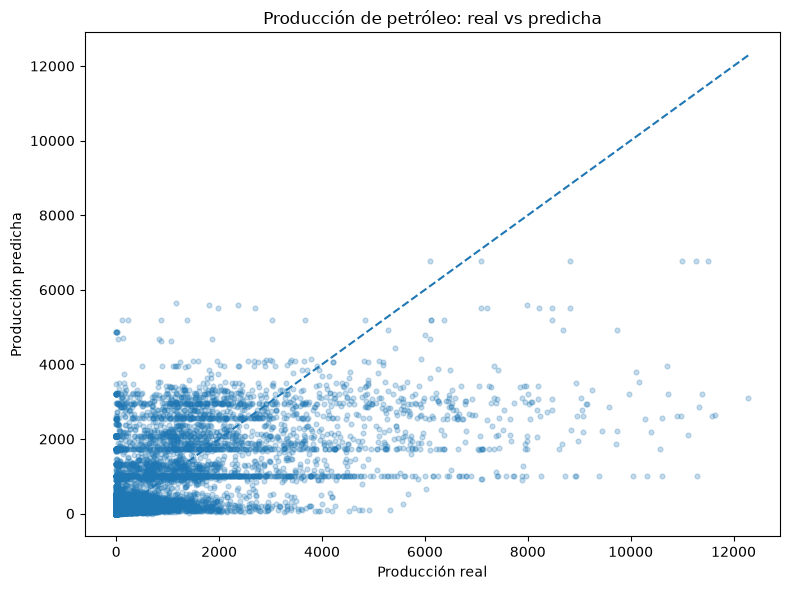

In [8]:
# Producción real vs producción predicha

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.25,
    s=12
)

limite = max(y_test.max(), y_pred.max())

plt.plot(
    [0, limite],
    [0, limite],
    "--"
)

plt.xlabel("Producción real")
plt.ylabel("Producción predicha")
plt.title("Producción de petróleo: real vs predicha")

plt.tight_layout()
plt.show()

In [9]:
# Análisis de errores por rango de producción

resultados = pd.DataFrame({
    "real": y_test.values,
    "predicha": y_pred
})

resultados["error_absoluto"] = abs(
    resultados["real"] - resultados["predicha"]
)

resultados["rango"] = pd.cut(
    resultados["real"],
    bins=[0, 100, 500, 1000, 5000, float("inf")],
    labels=[
        "0-100",
        "100-500",
        "500-1000",
        "1000-5000",
        ">5000"
    ],
    include_lowest=True
)

error_por_rango = (
    resultados
    .groupby("rango", observed=True)
    .agg(
        registros=("real", "size"),
        produccion_media=("real", "mean"),
        prediccion_media=("predicha", "mean"),
        mae=("error_absoluto", "mean")
    )
    .round(2)
)

error_por_rango

,registros,produccion_media,prediccion_media,mae
rango,,,,
0-100,52633,34.14,92.53,63.30
100-500,12349,193.21,159.15,125.39
500-1000,1809,697.43,565.36,563.92
1000-5000,2376,2128.47,1628.14,1110.83
>5000,313,6931.01,2539.27,4396.05


In [10]:
# Analizar historial disponible por pozo

historial_pozos = (
    df[df["prod_pet"] > 0]
    .groupby("idpozo")
    .agg(
        registros=("prod_pet", "size"),
        produccion_media=("prod_pet", "mean"),
        produccion_max=("prod_pet", "max")
    )
)

print("Cantidad de pozos:", len(historial_pozos))
print("\nCantidad de registros por pozo:")
print(historial_pozos["registros"].describe())

historial_pozos.head()

Cantidad de pozos: 26245

Cantidad de registros por pozo:
count    26245.000000
mean        10.769747
std          2.729872
min          1.000000
25%         12.000000
50%         12.000000
75%         12.000000
max         12.000000
Name: registros, dtype: float64


,registros,produccion_media,produccion_max
idpozo,,,
212,12,61.511667,69.49
214,12,78.615000,87.61
215,12,54.332500,65.00
216,12,41.245000,45.73
217,12,24.421667,26.06


In [11]:
# Crear producción del mes anterior por pozo

df_lag = df[
    [
        "idpozo",
        "mes",
        "prod_pet",
        "iny_agua",
        "iny_gas",
        "tef",
        "tipoextraccion",
        "tipoestado",
        "tipopozo",
        "provincia",
        "cuenca"
    ]
].copy()

# Orden cronológico dentro de cada pozo
df_lag = df_lag.sort_values(["idpozo", "mes"])

# Producción del pozo en el mes anterior
df_lag["prod_pet_lag1"] = (
    df_lag
    .groupby("idpozo")["prod_pet"]
    .shift(1)
)

print("Registros totales:", len(df_lag))
print("Registros con lag disponible:", df_lag["prod_pet_lag1"].notna().sum())
print("Registros sin lag:", df_lag["prod_pet_lag1"].isna().sum())

df_lag[
    ["idpozo", "mes", "prod_pet", "prod_pet_lag1"]
].head(20)

Registros totales: 991844
Registros con lag disponible: 908672
Registros sin lag: 83172


,idpozo,mes,prod_pet,prod_pet_lag1
757098,212,1,63.15,NaN
757152,212,2,53.37,63.15
757241,212,3,58.82,53.37
757285,212,4,61.52,58.82
757370,212,5,69.49,61.52
757408,212,6,59.78,69.49
757475,212,7,53.60,59.78
757545,212,8,69.08,53.60
757601,212,9,61.93,69.08
757661,212,10,63.00,61.93


In [12]:
# Dataset con historial del pozo

df_lag_modelo = df_lag[
    (df_lag["prod_pet"] > 0) &
    (df_lag["prod_pet_lag1"].notna())
].copy()

# Separación temporal
train_lag = df_lag_modelo[df_lag_modelo["mes"] <= 9]
test_lag = df_lag_modelo[df_lag_modelo["mes"] >= 10]

X_train_lag = train_lag.drop(columns=["prod_pet", "idpozo"])
y_train_lag = train_lag["prod_pet"]

X_test_lag = test_lag.drop(columns=["prod_pet", "idpozo"])
y_test_lag = test_lag["prod_pet"]

print("Train:", X_train_lag.shape)
print("Test:", X_test_lag.shape)

print("\nVariables:")
print(X_train_lag.columns.tolist())

Train: (188761, 10)
Test: (69372, 10)

Variables:
['mes', 'iny_agua', 'iny_gas', 'tef', 'tipoextraccion', 'tipoestado', 'tipopozo', 'provincia', 'cuenca', 'prod_pet_lag1']


In [13]:
# Preprocessor incluyendo producción del mes anterior

columnas_numericas_lag = [
    "mes",
    "iny_agua",
    "iny_gas",
    "tef",
    "prod_pet_lag1"
]

columnas_categoricas_lag = [
    "tipoextraccion",
    "tipoestado",
    "tipopozo",
    "provincia",
    "cuenca"
]

preprocessor_lag = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            columnas_categoricas_lag
        )
    ],
    remainder="passthrough"
)

modelo_lag = Pipeline([
    ("preprocessor", preprocessor_lag),
    ("regressor", RandomForestRegressor(
        n_estimators=150,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

print("Entrenando modelo con historial...")

modelo_lag.fit(X_train_lag, y_train_lag)

print("Modelo entrenado correctamente.")

Entrenando modelo con historial...
Modelo entrenado correctamente.


In [14]:
# Evaluar modelo con historial

y_pred_lag = modelo_lag.predict(X_test_lag)

mae_lag = mean_absolute_error(y_test_lag, y_pred_lag)
rmse_lag = np.sqrt(mean_squared_error(y_test_lag, y_pred_lag))
r2_lag = r2_score(y_test_lag, y_pred_lag)

print("=== MODELO SIN HISTORIAL ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

print("\n=== MODELO CON LAG 1 ===")
print(f"MAE:  {mae_lag:.2f}")
print(f"RMSE: {rmse_lag:.2f}")
print(f"R²:   {r2_lag:.4f}")

=== MODELO SIN HISTORIAL ===
MAE:  142.71
RMSE: 470.91
R²:   0.4549

=== MODELO CON LAG 1 ===
MAE:  44.46
RMSE: 241.10
R²:   0.8562


In [15]:
# Evaluación por mes

resultados_lag = pd.DataFrame({
    "mes": X_test_lag["mes"].values,
    "real": y_test_lag.values,
    "predicha": y_pred_lag
})

metricas_mes = (
    resultados_lag
    .groupby("mes")
    .apply(
        lambda x: pd.Series({
            "registros": len(x),
            "MAE": mean_absolute_error(x["real"], x["predicha"]),
            "RMSE": np.sqrt(mean_squared_error(x["real"], x["predicha"])),
            "R2": r2_score(x["real"], x["predicha"])
        }),
        include_groups=False
    )
    .round(2)
)

metricas_mes

,registros,MAE,RMSE,R2
mes,,,,
10,23233.0,43.76,250.50,0.85
11,23053.0,43.69,224.61,0.86
12,23086.0,45.93,247.29,0.86


In [16]:
import joblib
from pathlib import Path

# Crear carpeta para modelos
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

# Guardar pipeline completo
ruta_modelo = models_dir / "modelo_produccion_petroleo.joblib"

joblib.dump(modelo_lag, ruta_modelo)

print(f"Modelo guardado en: {ruta_modelo}")
print(f"Tamaño: {ruta_modelo.stat().st_size / 1024 / 1024:.2f} MB")

Modelo guardado en: ..\models\modelo_produccion_petroleo.joblib
Tamaño: 80.70 MB
